Name- Aryan Saini

B.Tech CSE 3rd year

section- C

cu24250069

computer vision labsheet 6



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from google.colab import files

Saving Coins Stacked up!.jpg to Coins Stacked up!.jpg


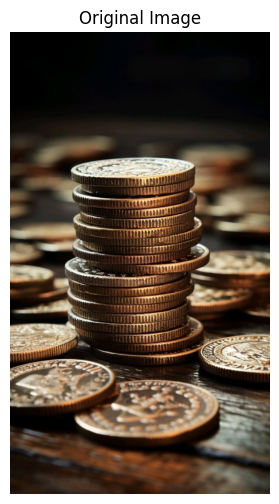

In [2]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)

# Convert BGR to RGB for displaying with Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

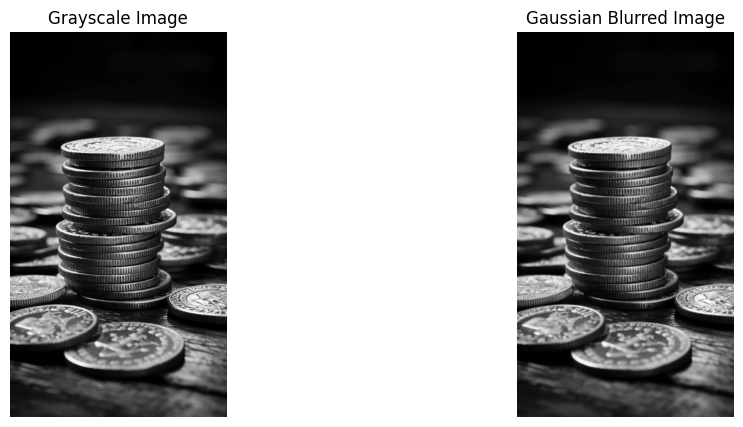

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

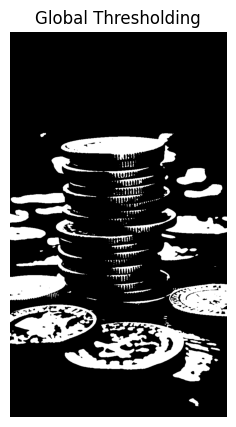

In [4]:
threshold_value = 127

_, global_thresh = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(7, 5))
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

Otsu Threshold Value: 90.0


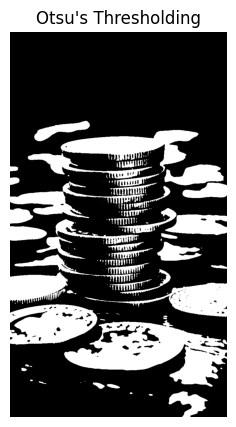

In [5]:
otsu_value, otsu_thresh = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Threshold Value:", otsu_value)

plt.figure(figsize=(7, 5))
plt.imshow(otsu_thresh, cmap='gray')
plt.title("Otsu's Thresholding")
plt.axis("off")
plt.show()

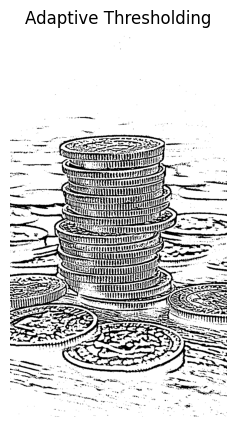

In [6]:
adaptive_thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(7, 5))
plt.imshow(adaptive_thresh, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

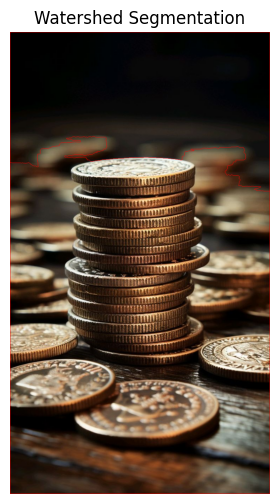

In [7]:
# Convert to binary
_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# Marker labeling
num_labels, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Apply Watershed
watershed_image = image.copy()

markers = cv2.watershed(
    watershed_image,
    markers
)

# Mark boundaries in red
watershed_image[markers == -1] = [0, 0, 255]

watershed_rgb = cv2.cvtColor(
    watershed_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 6))
plt.imshow(watershed_rgb)
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

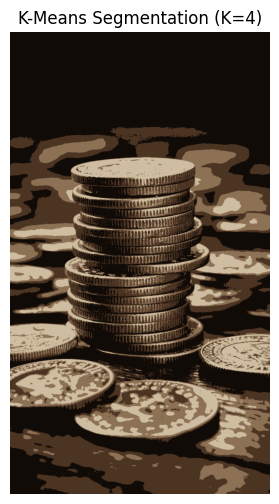

In [8]:
# Convert image to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Reshape pixels
pixel_data = rgb.reshape((-1, 3))
pixel_data = np.float32(pixel_data)

# Number of clusters
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixel_data)

# Cluster centers
centers = np.uint8(kmeans.cluster_centers_)

# Replace each pixel with its cluster center
segmented_data = centers[labels]

segmented_image = segmented_data.reshape(rgb.shape)

plt.figure(figsize=(8, 6))
plt.imshow(segmented_image)
plt.title("K-Means Segmentation (K=4)")
plt.axis("off")
plt.show()

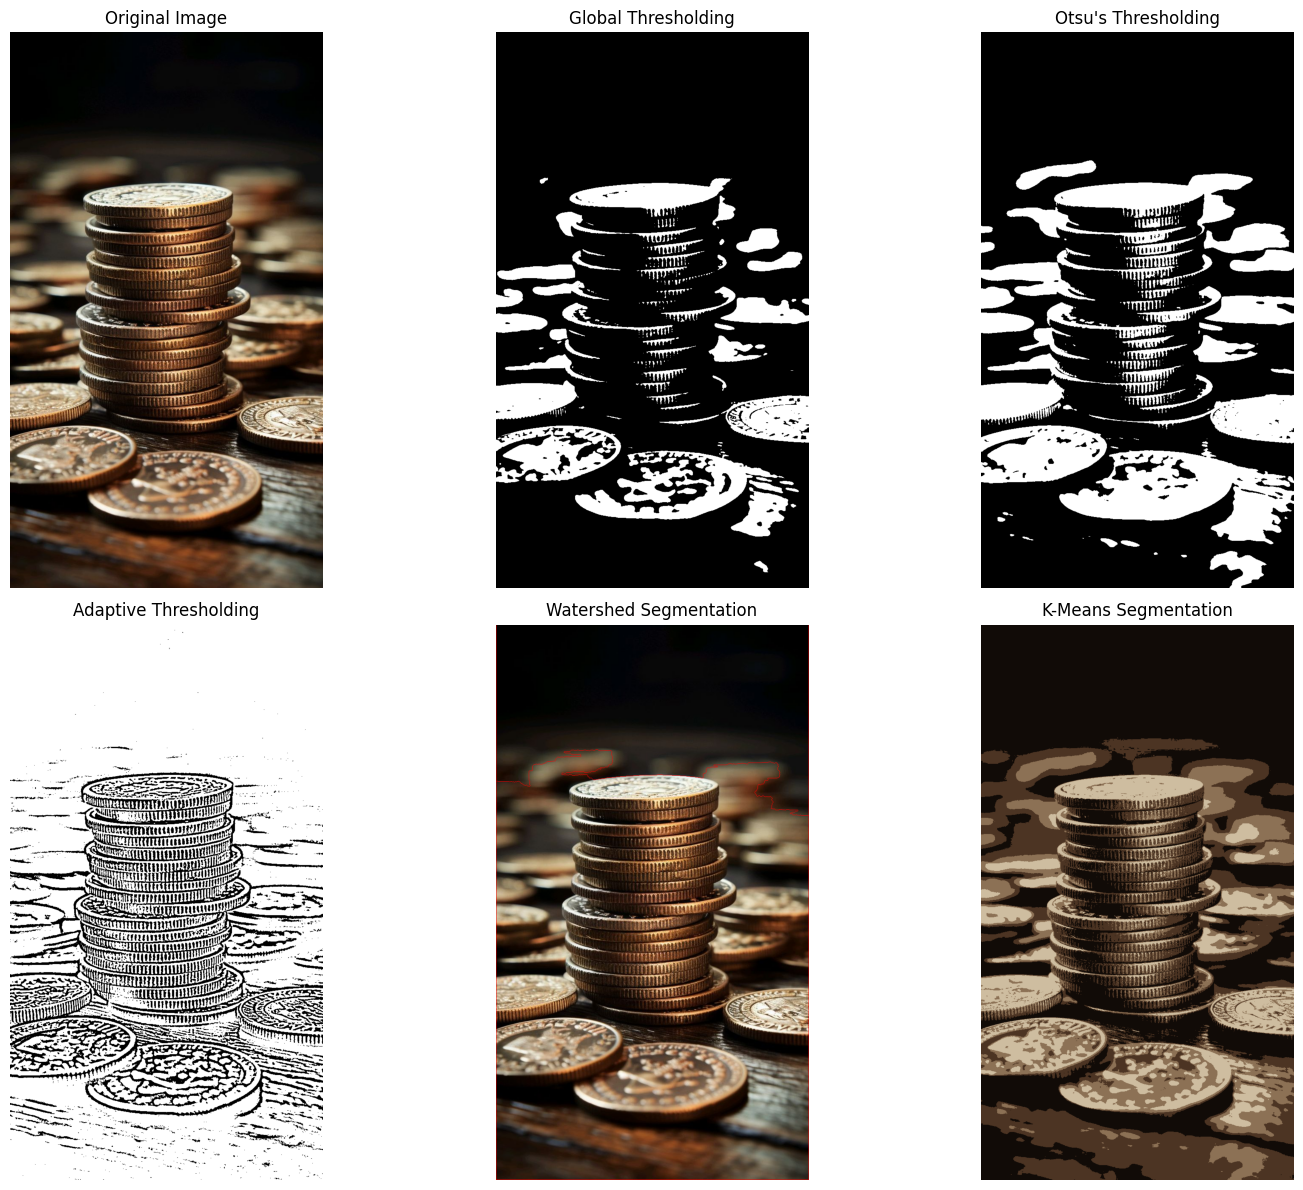

In [9]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_rgb)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

**Observations**

* Global Thresholding produced a binary segmentation using a fixed threshold. Otsu's method automatically selected a threshold and provided a more adaptive separation of foreground and background. Adaptive Thresholding performed segmentation using local regions and was useful when illumination was not uniform. Watershed segmentation identified object boundaries and was useful for separating touching objects. K-Means grouped pixels according to their color similarity and produced a color-based segmentation.

**Conclusion**

* Image segmentation successfully divided the input image into meaningful regions using different techniques. Threshold-based methods were simple and computationally efficient, while Watershed was useful for separating touching objects. K-Means provided effective color-based segmentation. The choice of segmentation technique depends on image characteristics such as illumination, background complexity, object boundaries, and color variation.



**Q & A**

1. What is image segmentation? Why is it considered a fundamental step in computer vision?

Answer:
Image segmentation is the process of dividing an image into multiple meaningful regions or objects based on properties such as pixel intensity, color, texture, or boundaries. It helps separate the foreground/object of interest from the background.

It is a fundamental step in computer vision because it makes it easier to analyze individual objects or regions. Segmentation is used in applications such as object detection, medical diagnosis, autonomous navigation, and industrial inspection.

2. Differentiate between Image Segmentation and Image Classification.

| Image Segmentation                                         | Image Classification                                      |
| ---------------------------------------------------------- | --------------------------------------------------------- |
| Divides an image into meaningful regions or objects.       | Assigns a class or category to an entire image or object. |
| Provides information about **where** an object is located. | Provides information about **what** the object is.        |
| Produces pixel-level or region-level output.               | Usually produces a class label.                           |
| Example: Separating coins from the background.             | Example: Classifying an image as "coin" or "flower".      |

In simple words: Classification tells us what is present, while segmentation tells us where it is.

3. Explain the working principle of Global Thresholding, Otsu's Thresholding, and Adaptive Thresholding.

Global Thresholding

Global thresholding uses a single threshold value for the entire image. Pixels above or below the threshold are assigned to different regions.

For example:

If pixel intensity > T → White


If pixel intensity ≤ T → Black

It works well when the image has relatively uniform illumination.

* Otsu's Thresholding

Otsu's method automatically determines an appropriate threshold value from the image histogram. It attempts to separate the image into foreground and background by selecting a threshold that provides good separation between the two intensity groups.

* Adaptive Thresholding

Adaptive thresholding calculates different threshold values for different local regions of the image. Therefore, it is useful when the image has uneven or varying illumination.


4. What is the Watershed Algorithm? Why is it useful for separating overlapping objects?

Answer:
The Watershed Algorithm is an image segmentation technique that treats an image like a topographical surface. Different regions are identified based on intensity and boundaries, and watershed lines are created between neighboring regions.

It is particularly useful for separating touching or overlapping objects.

For example, if several coins are touching each other, ordinary thresholding may consider them as one connected object. Watershed can identify the individual coins and separate them into different regions.

This is one of the reasons the coins image you selected is a good choice for this experiment.

5. How is K-Means Clustering applied to image segmentation?

Answer:
K-Means clustering segments an image by grouping pixels with similar characteristics into K clusters.

The basic process is:

1. Read the image.
2. Represent each pixel using its color values, such as RGB.
3. Select the number of clusters, K.
4. K-Means groups similar pixels into K clusters.
5. Calculate the cluster centers.
6. Replace each pixel with the color of its corresponding cluster.
7. Reshape the pixels back into the original image dimensions.

For example, if K = 4, the image is divided into four color-based regions.

K-Means is therefore useful for color-based image segmentation.

6. Compare threshold-based segmentation and clustering-based segmentation techniques.

| Threshold-Based Segmentation                                      | Clustering-Based Segmentation                                     |
| ----------------------------------------------------------------- | ----------------------------------------------------------------- |
| Uses threshold values to separate regions.                        | Groups similar pixels into clusters.                              |
| Usually works on intensity/grayscale values.                      | Can use color and other pixel features.                           |
| Generally simple and fast.                                        | Usually more computationally demanding.                           |
| Requires an appropriate threshold.                                | Requires selecting the number of clusters.                        |
| Examples: Global, Otsu, Adaptive Thresholding.                    | Example: K-Means Clustering.                                      |
| Suitable for images with clear foreground/background differences. | Suitable when regions can be distinguished by feature similarity. |


7. What challenges are encountered while segmenting images with complex backgrounds or varying illumination?

Answer:
Several challenges can affect image segmentation:

1. Complex backgrounds can have colors or intensities similar to the object.
2. Uneven illumination can make the same object appear with different brightness levels.
3. Noise can create unwanted regions.
4. Overlapping objects can make it difficult to identify individual objects.
5. Low contrast between foreground and background can make separation difficult.
6. Shadows and reflections can produce incorrect segmentation.
7. Object boundaries may not be clearly defined.

Therefore, the segmentation technique must be selected according to the characteristics of the image.

8. Mention five real-world applications where image segmentation plays a critical role.

Answer:

1. Medical Imaging — identifying tumors, organs, and abnormal regions.
2. Autonomous Vehicles — separating roads, vehicles, pedestrians, and other objects.
3. Satellite Imaging — identifying buildings, roads, vegetation, and land regions.
4. Industrial Inspection — detecting defects in manufactured products.
5. Object Detection and Recognition — separating objects from their background for further analysis.

These applications relate directly to the role of segmentation in isolating regions of interest described in the experiment.

9. How does image segmentation improve the performance of object detection and image recognition systems?

Answer:
Image segmentation separates important objects or regions from the background. This reduces unnecessary information and allows a computer vision system to focus on the region of interest (ROI).

As a result, segmentation can:

* Improve object localization.
* Reduce background interference.
* Provide more accurate object boundaries.
* Help identify individual objects.
* Make subsequent image analysis easier.
* Improve the effectiveness of object detection and recognition systems.

Thus, segmentation acts as an important preprocessing or analysis step for many computer vision tasks.

10. Compare traditional image segmentation techniques with deep learning-based segmentation methods such as U-Net and Mask R-CNN.

| Traditional Segmentation                                                | Deep Learning Segmentation                                     |
| ----------------------------------------------------------------------- | -------------------------------------------------------------- |
| Uses manually designed algorithms/rules.                                | Uses trained neural networks.                                  |
| Examples include thresholding, Watershed, and K-Means.                  | Examples include U-Net and Mask R-CNN.                         |
| Usually requires less computational power.                              | Usually requires greater computational resources.              |
| Can work well on relatively simple images.                              | Can handle complex visual patterns when trained appropriately. |
| Often depends heavily on image characteristics and parameter selection. | Learns useful features from training data.                     |
| Usually easier to implement and understand.                             | Generally more complex to train and implement.                 |
| May struggle with highly complex scenes.                                | Can perform advanced pixel/instance-level segmentation.        |


U-Net is commonly used for pixel-level/semantic segmentation, particularly where precise region boundaries are important. Mask R-CNN performs instance-level segmentation, allowing different objects of the same class to be identified separately.

